# Home Credit Default Risk

This project focuses on developing a credit risk model that estimates, at the time of loan application, the probability that a client will experience repayment difficulties in the future. The model uses only information available before the lending decision, including the applicant’s current financial situation and past or existing credit history.

### Target Variable

The target variable `TARGET` indicates whether a client experienced repayment difficulties:

- `TARGET = 0` — no repayment difficulties.
- `TARGET = 1` — repayment difficulties occurred.

The objective of the project is to estimate the probability of `TARGET = 1` using information available at the time of the loan application.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)

## 1. Loading and Initial Analysis of the Main Dataset

In [2]:
data = pd.read_csv('data/application_train.csv')
data.head() # Preview the dataset

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
data.shape # Dataset dimensions

(307511, 122)

In [4]:
# Missing values
columns_missings = ((data.isna().mean())*100).sort_values(ascending=False) # for columns in %
columns_missings

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
                              ...    
NAME_HOUSING_TYPE            0.000000
NAME_FAMILY_STATUS           0.000000
NAME_EDUCATION_TYPE          0.000000
NAME_INCOME_TYPE             0.000000
SK_ID_CURR                   0.000000
Length: 122, dtype: float64

In [5]:
rows_missings = ((data.isna().sum(axis=1)/data.shape[1])*100).sort_values(ascending=False) # for rows in %
rows_missings

185713    50.0
133770    50.0
197736    50.0
116937    50.0
269492    50.0
          ... 
129942     0.0
129929     0.0
129924     0.0
129911     0.0
153755     0.0
Length: 307511, dtype: float64

### Initial Findings on Missing Values

- The dataset contains 307,511 observations and 122 features.
- Several building-related features contain approximately 70% missing values.
- No features or observations were removed at this stage.
- The missing-value treatment strategy will be determined during data preprocessing and model comparison.

In [6]:
data["SK_ID_CURR"].duplicated(keep=False).sum()

np.int64(0)

- SK_ID_CURR is unique for all 307,511 observations.
- No duplicated application identifiers were detected.

In [7]:
data.info(max_cols=122)

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  str    
 3    CODE_GENDER                   307511 non-null  str    
 4    FLAG_OWN_CAR                  307511 non-null  str    
 5    FLAG_OWN_REALTY               307511 non-null  str    
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  str    
 12   NAME_INCOME_TYPE              307511 no

There are:

- float64 - 65 features
- int64 - 41 features
- str - 16 features

In [8]:
data.nunique(dropna=False)

SK_ID_CURR                    307511
TARGET                             2
NAME_CONTRACT_TYPE                 2
CODE_GENDER                        3
FLAG_OWN_CAR                       2
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY         10
AMT_REQ_CREDIT_BUREAU_WEEK        10
AMT_REQ_CREDIT_BUREAU_MON         25
AMT_REQ_CREDIT_BUREAU_QRT         12
AMT_REQ_CREDIT_BUREAU_YEAR        26
Length: 122, dtype: int64

The number of unique values in each feature is shown above.

Also:

- SK_ID_CURR contains 307,511 unique values, confirming that each application has a unique identifier.
- Several features have a small number of unique values and will be examined further during EDA and data preprocessing.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Analysis

In [9]:
data['TARGET'].value_counts(normalize=True) * 100 #values of target in percent

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

91.927% of applicants belong to class 0, indicating no repayment difficulties, while 8.072% belong to class 1 and experienced repayment difficulties. This distribution indicates a significant class imbalance.

In [10]:
# Describe data
data.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

After checking the descriptive statistics, I found that DAYS_EMPLOYED has a very large value that does not look realistic for work experience.

### 2.2 Investigation of DAYS_EMPLOYED

The 'DAYS_EMPLOYED' feature contains an unusually large maximum value of 365243 days. 
This value is substantially different from the rest of the distribution, so it requires 
further investigation to determine whether it represents a valid value or a special 
encoding used in the dataset.

In [11]:
# Check extreme DAYS_EMPLOYED values
data.loc[data['DAYS_EMPLOYED'] >= 200000, 'DAYS_EMPLOYED'].value_counts()

DAYS_EMPLOYED
365243    55374
Name: count, dtype: int64

Given the large number of such clients, I decided to create a new table containing this data to further investigate the value 365243.

In [12]:
# Creating a table
special_empl_gr = data[data['DAYS_EMPLOYED'] >= 200000] # special employment group

In [13]:
# Checking whether this is related to age
print('in age:', abs(data[data['DAYS_EMPLOYED'] >= 200000]['DAYS_BIRTH'].min())/365)
print('in days:', data[data['DAYS_EMPLOYED']>=200000]['DAYS_BIRTH'].min())

in age: 69.12054794520547
in days: -25229


In [14]:
# Checking whether this is related to age
print('in age:', abs(data[data['DAYS_EMPLOYED'] >= 200000]['DAYS_BIRTH'].max())/365)
print('in days:', data[data['DAYS_EMPLOYED']>=200000]['DAYS_BIRTH'].max())

in age: 21.07123287671233
in days: -7691


In [15]:
special_empl_gr[special_empl_gr['DAYS_BIRTH']==-25229]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
265026,406901,0,Revolving loans,F,N,Y,0,450000.0,2250000.0,225000.0,2250000.0,Unaccompanied,Pensioner,Higher education,Widow,House / apartment,0.072508,-25229,365243,-10147.0,-4166,NaN,1,0,0,1,1,1,NaN,1.0,1,1,SATURDAY,15,0,0,0,0,0,0,XNA,NaN,0.651023,NaN,0.1082,0.0985,0.9856,0.8028,0.0,0.08,0.0345,0.625,0.6667,0.0188,0.0883,0.099,0.0,0.0625,0.1103,0.1022,0.9856,0.8105,0.0,0.0806,0.0345,0.625,0.6667,0.0192,0.0964,0.1032,0.0,0.0662,0.1093,0.0985,0.9856,0.8054,0.0,0.08,0.0345,0.625,0.6667,0.0191,0.0898,0.1008,0.0,0.0639,reg oper account,block of flats,0.0915,Block,No,1.0,0.0,1.0,0.0,-151.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
special_empl_gr[special_empl_gr['DAYS_BIRTH']==-7691]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
29693,134473,0,Cash loans,F,N,Y,0,85500.0,255960.0,20353.5,202500.0,Unaccompanied,Pensioner,Secondary / secondary special,Single / not married,House / apartment,0.019689,-7691,365243,-2345.0,-321,NaN,1,0,0,1,0,0,NaN,1.0,2,2,TUESDAY,16,0,0,0,0,0,0,XNA,NaN,0.227508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-33.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Check income types in the special employment group
special_empl_gr['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

Among clients with DAYS_EMPLOYED = 365243, 55,352 are pensioners and 22 are unemployed.

In [18]:
# Check whether all pensioners have the special DAYS_EMPLOYED value
data[data['NAME_INCOME_TYPE']=='Pensioner'].shape

(55362, 122)

In [19]:
data[data['NAME_INCOME_TYPE']=='Unemployed'].shape

(22, 122)

The results show that 10 pensioners do not have the special value 365243 in DAYS_EMPLOYED.

In [20]:
# Displaying these 10 clients
pensioners_without_code = data[(data['NAME_INCOME_TYPE']=='Pensioner') & (data['DAYS_EMPLOYED'] != 365243)]
pensioners_without_code

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
18196,121224,0,Revolving loans,F,N,Y,0,94500.0,180000.0,9000.0,180000.0,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,0.018850,-20667,-1346,-945.0,-4221,NaN,1,1,1,1,1,0,NaN,2.0,2,2,FRIDAY,14,0,0,0,0,1,1,Business Entity Type 2,NaN,0.444632,0.216403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,1.0,4.0,1.0,-2447.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
33165,138428,0,Revolving loans,M,N,Y,1,76500.0,225000.0,11250.0,360000.0,NaN,Pensioner,Secondary / secondary special,Single / not married,Municipal apartment,0.031329,-18442,-5111,-11112.0,-1979,NaN,1,1,1,1,1,0,NaN,2.0,2,2,THURSDAY,10,0,0,0,0,0,0,Industry: type 9,NaN,0.162192,0.292588,0.0722,NaN,0.9791,NaN,NaN,0.0000,0.1379,0.1667,NaN,0.0695,NaN,0.0663,NaN,0.0000,0.0735,NaN,0.9791,NaN,NaN,0.0000,0.1379,0.1667,NaN,0.0710,NaN,0.0690,NaN,0.0000,0.0729,NaN,0.9791,NaN,NaN,0.00,0.1379,0.1667,NaN,0.0707,NaN,0.0674,NaN,0.0000,NaN,block of flats,0.0521,Panel,No,8.0,0.0,8.0,0.0,-711.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
106630,223714,0,Revolving loans,F,N,Y,0,157500.0,180000.0,9000.0,NaN,NaN,Pensioner,Secondary / secondary special,Widow,House / apartment,0.028663,-22105,-2341,-6447.0,-4837,NaN,1,1,1,1,1,0,Laborers,1.0,2,2,THURSDAY,8,0,0,0,0,1,1,Business Entity Type 3,NaN,0.460624,0.584990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,0.0,7.0,0.0,0.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
108373,225712,0,Revolving loans,F,N,Y,0,135000.0

These 10 pensioners were examined separately to understand why their employment information differs from the majority of pensioners in the dataset.

- A difference was identified in ORGANIZATION_TYPE between pensioners with and without the special DAYS_EMPLOYED value.

In [21]:
special_empl_gr['ORGANIZATION_TYPE'].value_counts()

ORGANIZATION_TYPE
XNA    55374
Name: count, dtype: int64

In [22]:
pensioners_without_code['ORGANIZATION_TYPE'].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    3
Business Entity Type 2    1
Industry: type 9          1
Medicine                  1
Military                  1
Trade: type 7             1
Self-employed             1
School                    1
Name: count, dtype: int64

All clients with DAYS_EMPLOYED = 365243 have ORGANIZATION_TYPE = XNA, including both pensioners and unemployed applicants.

The value 365243 in DAYS_EMPLOYED does not represent actual employment duration. It is concentrated among pensioners and unemployed applicants and is associated with undefined employment organization information. Therefore, it will be treated as a special encoded value during preprocessing rather than as a valid number of employment days.

### 2.3 Analysis of Selected Features and Their Relationship with TARGET

#### 2.3.1 Contract Type and Repayment Difficulties

In [23]:
# Analysis of categorical features
data['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

Analysis of repayment difficulties by NAME_CONTRACT_TYPE. The objective: to compare the repayment difficulty rate between different credit products.

In [24]:
data.groupby('NAME_CONTRACT_TYPE')['TARGET'].sum()

NAME_CONTRACT_TYPE
Cash loans         23221
Revolving loans     1604
Name: TARGET, dtype: int64

In [25]:
print(f'{round(data.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean()['Cash loans']*100, 3)}% repayment difficulty rate in Cash loans')
print(f'{round(data.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean()['Revolving loans']*100, 3)}% repayment difficulty rate in Revolving loans')

8.346% repayment difficulty rate in Cash loans
5.478% repayment difficulty rate in Revolving loans


In [26]:
data.groupby(['NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE'])['TARGET'].agg(['count', 'mean'])

count      mean
NAME_CONTRACT_TYPE NAME_INCOME_TYPE                      
Cash loans         Commercial associate   63652  0.078395
                   Maternity leave            2  1.000000
                   Pensioner              51993  0.054661
                   State servant          19836  0.059891
                   Student                   15  0.000000
                   Unemployed                15  0.533333
                   Working               142719  0.099433
Revolving loans    Businessman               10  0.000000
                   Commercial associate    7965  0.046453
                   Maternity leave            3  0.000000
                   Pensioner               3369  0.041555
                   State servant           1867  0.032673
                   Student                    3  0.000000
                   Unemployed                 7  0.000000
                   Working                16055  0.064341

In [27]:
data_group = data.groupby(['NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE'])['TARGET'].agg(['count', 'mean'])
data_group['repayment_difficulty_rate'] = data_group['mean']*100

income_repayment_stats = data_group.drop('mean', axis = 1) # # Repayment difficulty rate by contract and income type

In [28]:
income_repayment_stats

count  repayment_difficulty_rate
NAME_CONTRACT_TYPE NAME_INCOME_TYPE                                       
Cash loans         Commercial associate   63652                   7.839502
                   Maternity leave            2                 100.000000
                   Pensioner              51993                   5.466120
                   State servant          19836                   5.989111
                   Student                   15                   0.000000
                   Unemployed                15                  53.333333
                   Working               142719                   9.943315
Revolving loans    Businessman               10                   0.000000
                   Commercial associate    7965                   4.645323
                   Maternity leave            3                   0.000000
                   Pensioner               3369                   4.155536
                   State servant           1867                   3.267274
                   Student                    3                   0.000000
                   Unemployed                 7                   0.000000
                   Working                16055                   6.434133

In [29]:
income_repayment_stats = income_repayment_stats.reset_index()

In [30]:
# Keep sufficiently large segments for visualization
plot_data_1 = income_repayment_stats[income_repayment_stats['count']>100] # Creating data for visualisation
plot_data_1

,NAME_CONTRACT_TYPE,NAME_INCOME_TYPE,count,repayment_difficulty_rate
0,Cash loans,Commercial associate,63652,7.839502
2,Cash loans,Pensioner,51993,5.466120
3,Cash loans,State servant,19836,5.989111
6,Cash loans,Working,142719,9.943315
8,Revolving loans,Commercial associate,7965,4.645323
10,Revolving loans,Pensioner,3369,4.155536
11,Revolving loans,State servant,1867,3.267274
14,Revolving loans,Working,16055,6.434133


For visualization, only segments with more than 100 observations were retained to avoid drawing conclusions from very small groups.

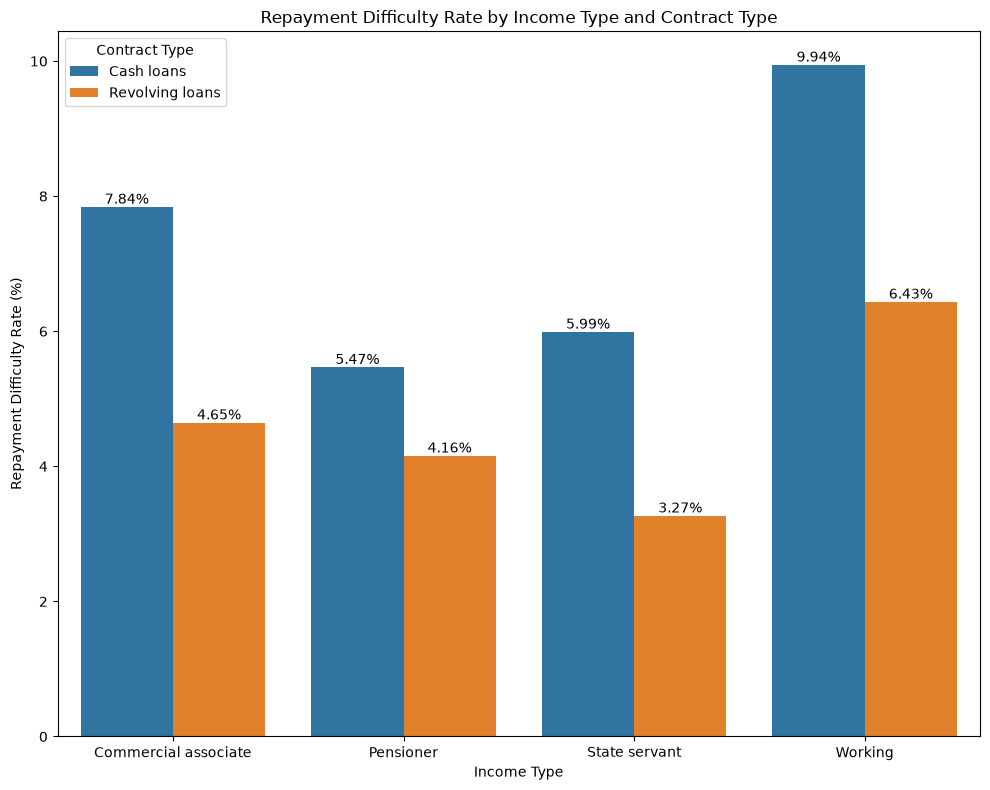

In [31]:
plt.figure(figsize=(10, 8))

ax_1 = sns.barplot(data = plot_data_1,
                 x = 'NAME_INCOME_TYPE',
                 y = 'repayment_difficulty_rate',
                 hue = 'NAME_CONTRACT_TYPE'
                )   


for container in ax_1.containers:
    ax_1.bar_label(container, fmt='%.2f%%')
    
plt.title('Repayment Difficulty Rate by Income Type and Contract Type')
plt.xlabel('Income Type')
plt.ylabel('Repayment Difficulty Rate (%)')
plt.legend(title='Contract Type')
plt.tight_layout()

# Save plot
plt.savefig(
    'outputs/figures/repayment_difficulty_rate_by_income_contract.png',
    dpi=300,
    bbox_inches='tight'
)

#Save table
plot_data_1.to_csv(
    'outputs/tables/repayment_difficulty_rate_by_income_contract.csv',
    index=False
)

plt.show()

The graph shows that the repayment difficulty rate is higher for Cash loans than for Revolving loans in all major income groups.

#### 2.3.2 Education Level and Repayment Difficulties

In [32]:
# Analyze the relationship between education level and repayment difficulties
data['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [33]:
data.groupby(['NAME_EDUCATION_TYPE', 'NAME_CONTRACT_TYPE'])['TARGET'].agg(['count', 'sum', 'mean' ])

count    sum      mean
NAME_EDUCATION_TYPE           NAME_CONTRACT_TYPE                         
Academic degree               Cash loans             146      3  0.020548
                              Revolving loans         18      0  0.000000
Higher education              Cash loans           65321   3694  0.056551
                              Revolving loans       9542    315  0.033012
Incomplete higher             Cash loans            9032    802  0.088795
                              Revolving loans       1245     70  0.056225
Lower secondary               Cash loans            3608    397  0.110033
                              Revolving loans        208     20  0.096154
Secondary / secondary special Cash loans          200125  18325  0.091568
                              Revolving loans      18266   1199  0.065641

Among sufficiently large education groups, Lower secondary has the highest repayment difficulty rate at approximately 10.9%, followed by Secondary / secondary special at approximately 8.9% and Incomplete higher at approximately 8.5%. Higher education has a lower rate of approximately 5.4%. The Academic degree category contains only 164 observations, so its rate should not be used for strong conclusions.

In [34]:
data.groupby(['NAME_EDUCATION_TYPE', 'TARGET'])['AMT_INCOME_TOTAL'].agg(['count', 'mean', 'median'])

count           mean    median
NAME_EDUCATION_TYPE           TARGET                                 
Academic degree               0          161  238472.049689  202500.0
                              1            3  322500.000000  337500.0
Higher education              0        70854  209354.906346  180000.0
                              1         4009  196230.025069  180000.0
Incomplete higher             0         9405  182036.386124  157500.0
                              1          872  176466.844610  157500.0
Lower secondary               0         3399  130211.115622  112500.0
                              1          417  129005.395683  117000.0
Secondary / secondary special 0       198867  154722.697425  135000.0
                              1        19524  159597.621159  135000.0

For additional analysis, client income was analyzed by education level and TARGET. In addition to the mean, the median was also calculated because it is less affected by high income values and outliers.

For Higher education, Incomplete higher, and Secondary / secondary special, the median income was the same for clients with and without repayment difficulties. At the same time, the median income was clearly different between education levels. This suggests that differences in median income alone do not explain the observed differences in repayment difficulty rates between education groups.

#### 2.3.3 Income and Financial Burden

In [35]:
income_analysis = data[['SK_ID_CURR', 'AMT_INCOME_TOTAL', 'TARGET']].copy()
income_analysis.head()

,SK_ID_CURR,AMT_INCOME_TOTAL,TARGET
0,100002,202500.0,1
1,100003,270000.0,0
2,100004,67500.0,0
3,100006,135000.0,0
4,100007,121500.0,0


In [36]:
income_analysis['income_bin'] = pd.qcut(
    income_analysis['AMT_INCOME_TOTAL'],
    q = 5 
)

income_analysis['income_bin'].value_counts().reset_index()

,income_bin,count
0,"(99000.0, 135000.0]",85756
1,"(162000.0, 225000.0]",75513
2,"(25649.999, 99000.0]",63671
3,"(225000.0, 117000000.0]",47118
4,"(135000.0, 162000.0]",35453


In [37]:
income_analysis['AMT_INCOME_TOTAL'].value_counts().head(10)

AMT_INCOME_TOTAL
135000.0    35750
112500.0    31019
157500.0    26556
180000.0    24719
90000.0     22483
225000.0    20698
202500.0    16341
67500.0     11147
270000.0    10827
81000.0      6001
Name: count, dtype: int64

In [38]:
income_bin_check = income_analysis.groupby(
                                            'income_bin'
                                            )['AMT_INCOME_TOTAL'].agg(['count', 'min', 'max']
                                          )

income_bin_check

,count,min,max
income_bin,,,
"(25649.999, 99000.0]",63671,25650.0,99000.0
"(99000.0, 135000.0]",85756,99031.5,135000.0
"(135000.0, 162000.0]",35453,135256.5,162000.0
"(162000.0, 225000.0]",75513,162279.0,225000.0
"(225000.0, 117000000.0]",47118,225112.5,117000000.0


The binning was checked and the intervals were divided correctly. The maximum value of each bin is slightly lower than the minimum value of the next bin, starting from the lowest income range.

In [39]:
income_analysis.groupby('income_bin')['TARGET'].agg(['count', 'mean'])

,count,mean
income_bin,,
"(25649.999, 99000.0]",63671,0.082062
"(99000.0, 135000.0]",85756,0.085883
"(135000.0, 162000.0]",35453,0.086847
"(162000.0, 225000.0]",75513,0.080569
"(225000.0, 117000000.0]",47118,0.065198


The relationship between income level and the repayment difficulty rate is not fully monotonic. In the first three income bins, the TARGET rate slightly increases as income increases. However, the rate decreases in the two higher-income groups, with the lowest rate observed in the highest income bin.

In [40]:
data['AMT_INCOME_TOTAL'].nlargest(10)

12840     117000000.0
203693     18000090.0
246858     13500000.0
77768       9000000.0
131127      6750000.0
103006      4500000.0
187833      4500000.0
204564      4500000.0
287463      4500000.0
181698      3950059.5
Name: AMT_INCOME_TOTAL, dtype: float64

Extremely high income values are present in a very small number of observations. They are retained during EDA and will be considered during preprocessing.

In [41]:
plot_data_2 = income_analysis.groupby('income_bin')['TARGET'].agg(
    ['count', 'mean']
    ).reset_index()

plot_data_2['repayment_difficulty_rate'] = plot_data_2['mean']*100
plot_data_2

,income_bin,count,mean,repayment_difficulty_rate
0,"(25649.999, 99000.0]",63671,0.082062,8.206248
1,"(99000.0, 135000.0]",85756,0.085883,8.588320
2,"(135000.0, 162000.0]",35453,0.086847,8.684738
3,"(162000.0, 225000.0]",75513,0.080569,8.056891
4,"(225000.0, 117000000.0]",47118,0.065198,6.519801


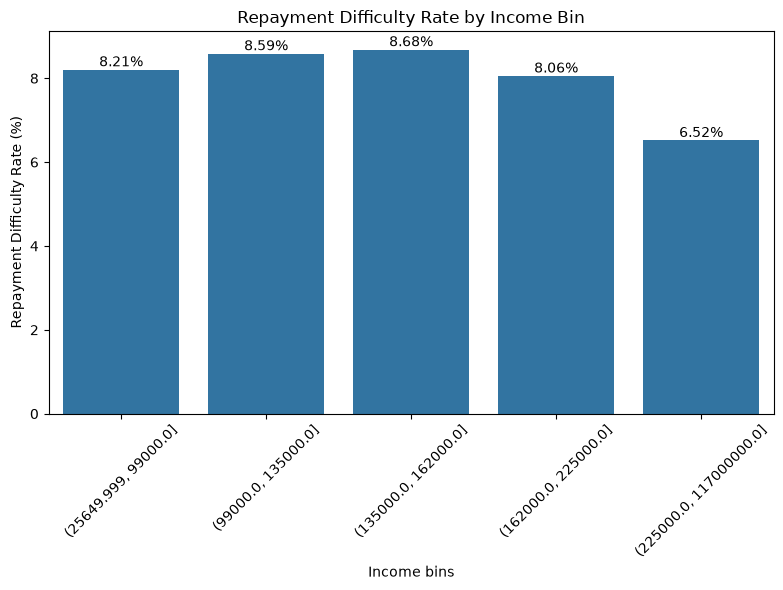

In [42]:
# Create plot
plt.figure(figsize = (8, 6))

ax_2 = sns.barplot(data = plot_data_2,
                   x = 'income_bin',
                   y = 'repayment_difficulty_rate')

for container in ax_2.containers:
    ax_2.bar_label(container, fmt='%.2f%%')
    
plt.title('Repayment Difficulty Rate by Income Bin')
plt.xlabel('Income bins')
plt.ylabel('Repayment Difficulty Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

# Save plot
plt.savefig(
    'outputs/figures/repayment_difficulty_rate_by_income_bin.png',
    dpi=300,
    bbox_inches='tight'
)

#Save table
plot_data_2.to_csv(
    'outputs/tables/repayment_difficulty_rate_by_income_bin.csv',
    index=False
)

plt.show()

In [43]:
# Check missing and zero values before creating financial ratios
print(data[['AMT_INCOME_TOTAL', 'AMT_ANNUITY']].isna().sum()) # Check for missing values
print((data[['AMT_INCOME_TOTAL', 'AMT_ANNUITY']] == 0).sum()) # Check for zero values

AMT_INCOME_TOTAL     0
AMT_ANNUITY         12
dtype: int64
AMT_INCOME_TOTAL    0
AMT_ANNUITY         0
dtype: int64


In [44]:
financial_analysis = data[
    ['SK_ID_CURR', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_CREDIT', 'NAME_INCOME_TYPE', 'TARGET']
].copy()

financial_analysis['ANNUITY_INCOME_RATIO'] = (
    financial_analysis['AMT_ANNUITY'] 
    / financial_analysis['AMT_INCOME_TOTAL']
)

print(financial_analysis['ANNUITY_INCOME_RATIO'].describe())

count    307499.000000
mean          0.180930
std           0.094574
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965
Name: ANNUITY_INCOME_RATIO, dtype: float64


ANNUITY_INCOME_RATIO is used as a simple proxy for relative payment burden rather than as a formal DTI or DSTI measure. A high maximum value of approximately 1.877 is observed, so the upper part of the distribution is examined separately. AMT_CREDIT and NAME_INCOME_TYPE are included to provide additional context.

In [45]:
financial_analysis.sort_values(
    'ANNUITY_INCOME_RATIO',
    ascending=False
).head(10)

,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_ANNUITY,AMT_CREDIT,NAME_INCOME_TYPE,TARGET,ANNUITY_INCOME_RATIO
20727,124157,25650.0,48118.5,2173500.0,Pensioner,1,1.875965
197677,329192,45000.0,70677.0,743031.0,Pensioner,0,1.570600
247615,386520,31500.0,45724.5,679500.0,Commercial associate,0,1.451571
226137,361920,45000.0,62698.5,1800000.0,Pensioner,1,1.393300
678,100784,54000.0,74191.5,1885500.0,Pensioner,1,1.373917
205575,338291,36000.0,48627.0,1223010.0,Pensioner,1,1.350750
35791,141454,45000.0,58567.5,2215224.0,Pensioner,0,1.301500
293599,440148,33165.0,42790.5,1006920.0,Pensioner,0,1.290231
200894,332872,40500.0,51948.0,1223010.0,Working,0,1.282667
173546,301115,27000.0,32337.0,760225.5,Pensioner,0,1.197667


In [46]:
financial_analysis['ANNUITY_INCOME_bin'] = pd.qcut(
    financial_analysis['ANNUITY_INCOME_RATIO'],
    q = 5
)

financial_analysis['ANNUITY_INCOME_bin'].value_counts()

ANNUITY_INCOME_bin
(0.186, 0.247]        61522
(0.104, 0.144]        61507
(-0.000776, 0.104]    61500
(0.144, 0.186]        61494
(0.247, 1.876]        61476
Name: count, dtype: int64

In [47]:
financial_analysis.groupby('ANNUITY_INCOME_bin')['TARGET'].agg(['count', 'mean'])

,count,mean
ANNUITY_INCOME_bin,,
"(-0.000776, 0.104]",61500,0.071967
"(0.104, 0.144]",61507,0.078316
"(0.144, 0.186]",61494,0.081260
"(0.186, 0.247]",61522,0.086961
"(0.247, 1.876]",61476,0.085155


When ANNUITY_INCOME_RATIO is divided into 5 quantile groups, the repayment difficulty rate increases across the first four bins. However, this trend changes in the last bin, where the rate slightly decreases. The last bin also has a wide range of values from 0.247 to 1.876, so it was analyzed separately.

In [48]:
high_burden = financial_analysis[
    financial_analysis['ANNUITY_INCOME_RATIO'] > 0.247
].copy()

high_burden['high_burden_bin'] = pd.qcut(
    high_burden['ANNUITY_INCOME_RATIO'],
    q = 8
)

high_burden['high_burden_bin'].value_counts()

high_burden_bin
(0.285, 0.302]    7672
(0.302, 0.325]    7668
(0.246, 0.259]    7666
(0.355, 0.403]    7666
(0.259, 0.271]    7663
(0.403, 1.876]    7648
(0.271, 0.285]    7644
(0.325, 0.355]    7635
Name: count, dtype: int64

In [49]:
high_burden.groupby('high_burden_bin')['TARGET'].agg(['count', 'mean'])

,count,mean
high_burden_bin,,
"(0.246, 0.259]",7666,0.086877
"(0.259, 0.271]",7663,0.088216
"(0.271, 0.285]",7644,0.089351
"(0.285, 0.302]",7672,0.088895
"(0.302, 0.325]",7668,0.084507
"(0.325, 0.355]",7635,0.081860
"(0.355, 0.403]",7666,0.078920
"(0.403, 1.876]",7648,0.082767


After further splitting the upper range, the repayment difficulty rate increases until ANNUITY_INCOME_RATIO reaches approximately 0.28–0.30, after which it starts to decrease. A small increase is observed again in the final wide interval.

I decided to group the data by these bins and compare the repayment difficulty rate, as well as the median income, annuity payment, and credit amount.

In [50]:
high_burden.groupby('high_burden_bin')[
    ['AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_CREDIT']
].agg(['mean', 'median'])

AMT_INCOME_TOTAL             AMT_ANNUITY            \
                            mean    median          mean    median   
high_burden_bin                                                      
(0.246, 0.259]     138490.104611  135000.0  34987.237021  33414.75   
(0.259, 0.271]     131856.077907  121500.0  34931.593827  32602.50   
(0.271, 0.285]     128609.591998  112500.0  35752.511774  32004.00   
(0.285, 0.302]     123857.482664  112500.0  36337.763947  33259.50   
(0.302, 0.325]     120126.407823  112500.0  37590.876174  35419.50   
(0.325, 0.355]     113675.537917  112500.0  38507.325737  36927.00   
(0.355, 0.403]     105524.991371   94500.0  39771.365706  35964.00   
(0.403, 1.876]      87288.398243   81000.0  42287.036022  38331.00   

                    AMT_CREDIT             
                          mean     median  
high_burden_bin                            
(0.246, 0.259]   758336.067636  678996.00  
(0.259, 0.271]   771077.098786  689742.00  
(0.271, 0.285]   797534.300628  733315.50  
(0.285, 0.302]   796393.228233  755190.00  
(0.302, 0.325]   811753.949531  737165.25  
(0.325, 0.355]   842518.037917  780363.00  
(0.355, 0.403]   845977.207670  770292.00  
(0.403, 1.876]   880027.598457  808650.00

As ANNUITY_INCOME_RATIO increases, both the mean and median client income generally decrease, while the annuity payment increases. This shows that the growth of the ratio is related to both lower income and higher payment burden. AMT_CREDIT also generally increases, although the median values are not strictly monotonic.

In [51]:
pd.crosstab(
    high_burden['high_burden_bin'],
    high_burden['NAME_INCOME_TYPE'],
    normalize='index'
) * 100

NAME_INCOME_TYPE,Businessman,Commercial associate,Maternity leave,Pensioner,State servant,Student,Unemployed,Working
high_burden_bin,,,,,,,,
"(0.246, 0.259]",0.000000,20.740934,0.000000,19.319071,7.239760,0.000000,0.000000,52.700235
"(0.259, 0.271]",0.000000,20.683805,0.000000,20.266214,7.294793,0.013050,0.000000,51.742138
"(0.271, 0.285]",0.000000,20.081109,0.000000,19.911041,7.299843,0.013082,0.000000,52.694924
"(0.285, 0.302]",0.000000,19.603754,0.013034,21.728363,7.051616,0.000000,0.000000,51.603233
"(0.302, 0.325]",0.000000,19.705269,0.000000,21.674491,7.068336,0.000000,0.000000,51.551904
"(0.325, 0.355]",0.000000,18.258022,0.000000,23.366077,6.981009,0.013098,0.000000,51.381794
"(0.355, 0.403]",0.000000,18.353770,0.000000,23.949909,7.109314,0.000000,0.013045,50.573963
"(0.403, 1.876]",0.013075,13.885983,0.013075,30.570084,7.466004,0.000000,0.130753,47.921025


At higher values of ANNUITY_INCOME_RATIO, the client composition by NAME_INCOME_TYPE changes. The share of Pensioner generally increases and reaches around 30.6% in the last bin. The share of Working remains relatively stable across most bins and decreases to around 47.9% in the final bin, while the share of Commercial associate also decreases noticeably in the last bin. State servant remains relatively stable. Very small income groups are not used for strong conclusions.

#### 2.3.4 EXT_SOURCE Features

EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 are normalized scores obtained from external data sources. Their exact construction is not provided in the dataset description, so they are treated as external scores rather than probabilities.

In [52]:
ext_source_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

data[ext_source_cols].isna().sum() # Check for missing values

EXT_SOURCE_1    173378
EXT_SOURCE_2       660
EXT_SOURCE_3     60965
dtype: int64

In [53]:
data[ext_source_cols].describe()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,134133.000000,3.068510e+05,246546.000000
mean,0.502130,5.143927e-01,0.510853
std,0.211062,1.910602e-01,0.194844
min,0.014568,8.173617e-08,0.000527
25%,0.334007,3.924574e-01,0.370650
50%,0.505998,5.659614e-01,0.535276
75%,0.675053,6.636171e-01,0.669057
max,0.962693,8.549997e-01,0.896010


In [54]:
data[ext_source_cols].isna().mean()*100 # Percentage of gaps by ext_source_n

EXT_SOURCE_1    56.381073
EXT_SOURCE_2     0.214626
EXT_SOURCE_3    19.825307
dtype: float64

An analysis of missing values ​​for the EXT_SOURCE_n features revealed the count and proportion of missing data. The results show that EXT_SOURCE_1 has the highest rate of missing values ​​at 56.38%. EXT_SOURCE_3 stands at 19.82%, whereas EXT_SOURCE_2 has very few missing values—0.21%.

Descriptive statistics indicate that the values ​​for all three features fall within the 0 to 1 range. No obvious outliers were detected.

In [55]:
for col in ext_source_cols:
    print(f'\n{col}')
    print(
        data.groupby(data[col].isna())['TARGET']
        .agg(['count', 'mean'])
    )


EXT_SOURCE_1
               count      mean
EXT_SOURCE_1                  
False         134133  0.074955
True          173378  0.085195

EXT_SOURCE_2
               count      mean
EXT_SOURCE_2                  
False         306851  0.080733
True             660  0.078788

EXT_SOURCE_3
               count      mean
EXT_SOURCE_3                  
False         246546  0.077665
True           60965  0.093119


Clients with missing EXT_SOURCE_1 and EXT_SOURCE_3 have a higher repayment difficulty rate than clients with available values. For EXT_SOURCE_2, the difference is small, and the number of missing observations is very low. This suggests that missingness itself may contain useful information and should be considered during preprocessing.

In [56]:
ext_source_data = data[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']].copy()

ext_source_data.groupby(['TARGET'])[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].agg(['count', 'mean', 'median'])

EXT_SOURCE_1                     EXT_SOURCE_2                      \
              count      mean    median        count      mean    median   
TARGET                                                                     
0            124079  0.511461  0.517452       282078  0.523479  0.573905   
1             10054  0.386968  0.361675        24773  0.410935  0.440381   

       EXT_SOURCE_3                      
              count      mean    median  
TARGET                                   
0            227398  0.520969  0.546023  
1             19148  0.390717  0.379100

The results show that for all three EXT_SOURCE variables, the mean and median values ​​are lower for clients with TARGET = 1 than for those with TARGET = 0. This indicates an inverse relationship between the EXT_SOURCE value and repayment difficulties: lower external score values ​​are more frequently observed among clients experiencing repayment issues. Among clients with TARGET = 1, the highest mean value is observed for EXT_SOURCE_2—approximately 0.411.

In [57]:
# Creating bins to analyze the relationship between TARGET and EXT_SOURCE_n
ext_source_data['bins_EXT_SOURCE_1'] = pd.qcut(ext_source_data['EXT_SOURCE_1'], q=5)
ext_source_data['bins_EXT_SOURCE_2'] = pd.qcut(ext_source_data['EXT_SOURCE_2'], q=5)
ext_source_data['bins_EXT_SOURCE_3'] = pd.qcut(ext_source_data['EXT_SOURCE_3'], q=5)

In [58]:
print(ext_source_data.groupby(['bins_EXT_SOURCE_1'])['TARGET'].agg(['count', 'mean']))
print(ext_source_data.groupby(['bins_EXT_SOURCE_2'])['TARGET'].agg(['count', 'mean']))
print(ext_source_data.groupby(['bins_EXT_SOURCE_3'])['TARGET'].agg(['count', 'mean']))

                               count      mean
bins_EXT_SOURCE_1                             
(0.013600000000000001, 0.296]  26827  0.145786
(0.296, 0.438]                 26826  0.087378
(0.438, 0.573]                 26827  0.063593
(0.573, 0.71]                  26826  0.047603
(0.71, 0.963]                  26827  0.030417
                       count      mean
bins_EXT_SOURCE_2                     
(-0.0009999183, 0.34]  61371  0.152140
(0.34, 0.512]          61371  0.091607
(0.512, 0.608]         61371  0.070392
(0.608, 0.682]         61377  0.053652
(0.682, 0.855]         61361  0.035870
                   count      mean
bins_EXT_SOURCE_3                 
(-0.000473, 0.33]  49445  0.163758
(0.33, 0.476]      49746  0.087505
(0.476, 0.592]     49578  0.057505
(0.592, 0.694]     49470  0.044795
(0.694, 0.896]     48307  0.033763


This analysis showed that the repayment difficulty rate consistently decreases as the values ​​of EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 increase. This pattern is observed for all three features, showing a clear monotonic inverse relationship between the EXT_SOURCE values ​​and the likelihood of repayment difficulties.

In [59]:
# Correlation matrix for examining the relationship between EXT_SOURCE_n and TARGET
corr_cols = ['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
corr_matrix = data[corr_cols].corr()

corr_matrix

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,1.000000,-0.155317,-0.160472,-0.178919
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000


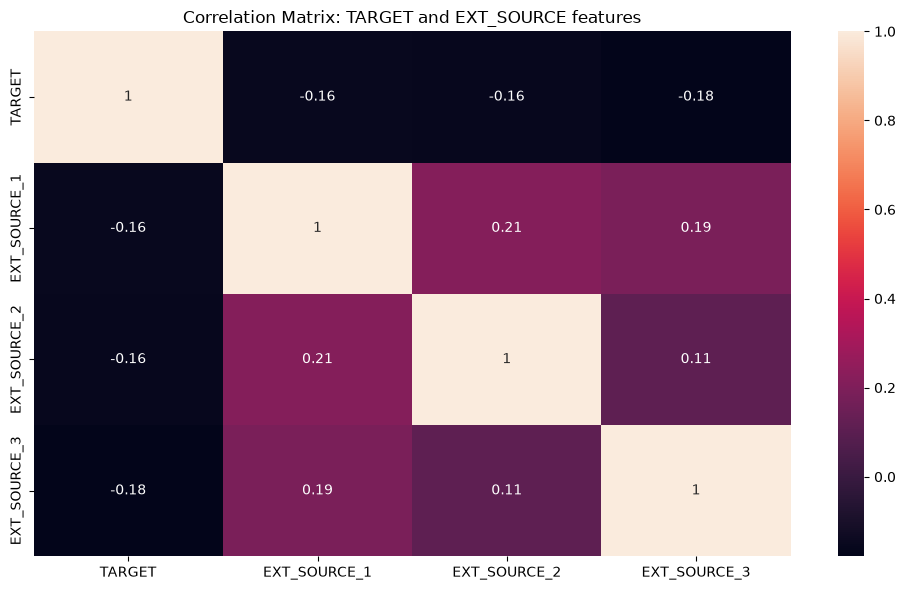

In [60]:
# Correlation Matrix
plt.figure(figsize=(10, 6))

sns.heatmap(
            corr_matrix, 
            annot=True,
           )

plt.title('Correlation Matrix: TARGET and EXT_SOURCE features')
plt.tight_layout()
# Save plot (Plot_3)
plt.savefig(
    'outputs/figures/Correlation_Matrix_TARGET_and_EXT_SOURCE_features.png',
    dpi=300,
    bbox_inches='tight'
)

#Save table
corr_matrix.to_csv(
    'outputs/tables/Correlation_Matrix_TARGET_and_EXT_SOURCE_features.csv',
)

plt.show()

According to the visualization, among the EXT_SOURCE_n variables, EXT_SOURCE_3 shows the strongest negative correlation with the target (-0.18). This indicates that higher EXT_SOURCE_3 values ​​are associated with a lower probability of repayment difficulties. EXT_SOURCE_1 and EXT_SOURCE_2 also exhibit a negative correlation with the TARGET—approximately -0.16.

The correlations between the EXT_SOURCE variables are low, ranging from 0.11 to 0.21. This suggests that there is no strong linear relationship between these features, so they may provide different information to the model.

#### 2.3.5 Client Age and Repayment Difficulties

In [61]:
data['DAYS_BIRTH'].isna().sum()

np.int64(0)

In [62]:
age_analysis = data[['DAYS_BIRTH', 'TARGET']].copy()

age_analysis['AGE_YEARS'] = -age_analysis['DAYS_BIRTH']/365

age_analysis.describe()

,DAYS_BIRTH,TARGET,AGE_YEARS
count,307511.000000,307511.000000,307511.000000
mean,-16036.995067,0.080729,43.936973
std,4363.988632,0.272419,11.956133
min,-25229.000000,0.000000,20.517808
25%,-19682.000000,0.000000,34.008219
50%,-15750.000000,0.000000,43.150685
75%,-12413.000000,0.000000,53.923288
max,-7489.000000,1.000000,69.120548


The descriptive statistics for age appear logical; there are no unexpected or anomalous values.

In [63]:
age_analysis['AGE_BIN'] = pd.qcut(
    age_analysis['AGE_YEARS'],
    q = 5
)

age_analysis.AGE_BIN.value_counts()

AGE_BIN
(20.517, 32.038]    61512
(39.496, 47.178]    61509
(32.038, 39.496]    61504
(56.093, 69.121]    61495
(47.178, 56.093]    61491
Name: count, dtype: int64

In [64]:
age_analysis.groupby('AGE_BIN')['TARGET'].agg(['count', 'mean'])

,count,mean
AGE_BIN,,
"(20.517, 32.038]",61512,0.112824
"(32.038, 39.496]",61504,0.093295
"(39.496, 47.178]",61509,0.078493
"(47.178, 56.093]",61491,0.067392
"(56.093, 69.121]",61495,0.051630


The repayment difficulty rate consistently decreases as the age of clients increases. The highest proportion of repayment difficulties is observed in the youngest age group, while the lowest is found in the oldest.

#### 2.3.6 Family Characteristics and Repayment Difficulties

In [65]:
family_cols = ['NAME_FAMILY_STATUS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']

data[family_cols].isna().sum() # Check for missing values

NAME_FAMILY_STATUS    0
CNT_CHILDREN          0
CNT_FAM_MEMBERS       2
dtype: int64

In [66]:
data['NAME_FAMILY_STATUS'].value_counts()

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

In [67]:
data[['CNT_CHILDREN', 'CNT_FAM_MEMBERS']].describe()

,CNT_CHILDREN,CNT_FAM_MEMBERS
count,307511.000000,307509.000000
mean,0.417052,2.152665
std,0.722121,0.910682
min,0.000000,1.000000
25%,0.000000,2.000000
50%,0.000000,2.000000
75%,1.000000,3.000000
max,19.000000,20.000000


Descriptive statistics show high maximum values ​​for CNT_CHILDREN and CNT_FAM_MEMBERS; therefore, the upper end of the distribution should be examined separately.

In [68]:
data['CNT_CHILDREN'].value_counts().reset_index()

,CNT_CHILDREN,count
0,0,215371
1,1,61119
2,2,26749
3,3,3717
4,4,429
5,5,84
6,6,21
7,7,7
8,14,3
9,8,2


In [69]:
# Data logic check: children and number of family members
data[data['CNT_CHILDREN'] > data['CNT_FAM_MEMBERS']][
    ['CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_FAMILY_STATUS']
    ]

,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS


High values ​​for CNT_CHILDREN occur extremely rarely and do not appear to indicate a systemic data issue. A logical check also confirmed that the number of children does not exceed the total number of family members.

In [70]:
data['CNT_FAM_MEMBERS'].value_counts().reset_index()

,CNT_FAM_MEMBERS,count
0,2.0,158357
1,1.0,67847
2,3.0,52601
3,4.0,24697
4,5.0,3478
5,6.0,408
6,7.0,81
7,8.0,20
8,9.0,6
9,10.0,3


High values ​​for CNT_FAM_MEMBERS occur very rarely and do not appear to be a systemic data issue. Most clients belong to small families of 1–4 members.

In [71]:
data.groupby('NAME_FAMILY_STATUS')['TARGET'].agg(['count', 'mean']).sort_values('mean', ascending=False)

,count,mean
NAME_FAMILY_STATUS,,
Civil marriage,29775,0.099446
Single / not married,45444,0.098077
Separated,19770,0.081942
Married,196432,0.075599
Widow,16088,0.058242
Unknown,2,0.000000


The highest repayment difficulty rate is observed in the "Civil marriage" group—approximately 9.9%—followed by the "Single / not married" group at around 9.8%. Among the main categories, the lowest rate is found in the "Widow" group—approximately 5.8%. The "Unknown" category contains only two observations; therefore, it should not be used to draw conclusions.

In [72]:
family_analysis = data[
    ['NAME_FAMILY_STATUS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'TARGET']
].copy()

family_analysis['CHILDREN_GROUP'] = pd.cut(
    family_analysis['CNT_CHILDREN'],
    bins=[-1, 0, 1, 2, 3, float('inf')],
    labels=['0', '1', '2', '3', '4+']
)

family_analysis['FAMILY_SIZE_GROUP'] = pd.cut(
    family_analysis['CNT_FAM_MEMBERS'],
    bins=[0, 1, 2, 3, 4, 5, float('inf')], # Two missing values remain as NaN
    labels=['1', '2', '3', '4', '5', '6+']
)

family_analysis.groupby(
    'CHILDREN_GROUP',
    observed=True
)['TARGET'].agg(['count', 'mean'])

,count,mean
CHILDREN_GROUP,,
0,215371,0.077118
1,61119,0.089236
2,26749,0.087218
3,3717,0.096314
4+,555,0.127928


Since the number of observations for families with four or more children is small—leading to noise in the data—I grouped these cases together to analyze the trend. I applied the same grouping method to the total number of family members.

After consolidating infrequent values ​​into a "4+" category, it is evident that the repayment difficulty rate generally rises as the number of children increases. While the relationship is not strictly monotonic—due to a slight dip between the one-child and two-child groups—the rate is noticeably higher for larger families.

In [73]:
family_analysis.groupby(
    'FAMILY_SIZE_GROUP',
    observed=True
)['TARGET'].agg(['count', 'mean'])

,count,mean
FAMILY_SIZE_GROUP,,
1,67847,0.083644
2,158357,0.075835
3,52601,0.087603
4,24697,0.086488
5,3478,0.094020
6+,529,0.132325


For CNT_FAM_MEMBERS, an overall increase in the repayment difficulty rate is also observed as family size grows, although the relationship is not strictly monotonic. The highest rate is observed in the "6+" group.

### 2.4 EDA Summary

The exploratory data analysis identified several important patterns and data quality considerations that will be taken into account during preprocessing and model development.
- The dataset contains 307,511 applications and 122 features. The target is highly imbalanced: approximately 8.1% of clients experienced repayment difficulties, while 91.9% did not.
- Several features contain a high proportion of missing values. In particular, many building-related variables have around 70% missing values. Among the external score features, EXT_SOURCE_1 has approximately 56.4% missing values and EXT_SOURCE_3 around 19.8%.
- DAYS_EMPLOYED contains the special value 365243, which does not represent actual employment duration. It is mainly observed among pensioners and unemployed clients and will therefore require special treatment during preprocessing.
- Cash loans show a higher repayment difficulty rate than Revolving loans. This pattern is also observed across the main income groups.
- Education level is associated with repayment difficulties. Clients with Higher education have a lower repayment difficulty rate, while Lower secondary and Secondary / secondary special groups show higher rates. Differences in median income alone do not explain this pattern.
- The relationship between income and repayment difficulties is not fully monotonic. However, the highest-income group has the lowest repayment difficulty rate among the analyzed income groups.
- ANNUITY_INCOME_RATIO shows a clear relationship with repayment difficulties. The repayment difficulty rate generally increases as the relative payment burden increases, although the relationship becomes non-monotonic at higher ratio levels.
- Higher values of EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 are consistently associated with lower repayment difficulty rates. Among these features, EXT_SOURCE_3 has the strongest negative correlation with TARGET.
- Repayment difficulties decrease consistently with client age. Younger clients show higher repayment difficulty rates than older clients.
- Family characteristics also show differences in repayment difficulties. Larger numbers of children and family members are generally associated with higher rates, although these relationships are not strictly monotonic. Civil marriage and Single / not married also show higher rates than some other family-status groups.

Overall, the EDA shows that client characteristics, external scores, financial burden, and family information contain potentially useful signals related to repayment difficulties. These findings will guide the preprocessing, feature engineering, and model development stages.

## 3. Preprocessing

### Preprocessing Strategy

During EDA, two main data quality issues were identified. First, the dataset contains missing values that should be reviewed to understand whether they represent natural absence of information or require treatment before modeling. Second, DAYS_EMPLOYED contains the special value 365243, mainly associated with specific client groups, and it should not be treated as a normal number of employment days.

Other preprocessing steps, such as categorical encoding and numerical transformations, will be selected based on the requirements of the models used later.

### 3.1 Missing Values and Special Values Analysis

In [74]:
# Check features with missing values
columns_missings[columns_missings > 0]

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
                              ...    
EXT_SOURCE_2                 0.214626
AMT_GOODS_PRICE              0.090403
AMT_ANNUITY                  0.003902
CNT_FAM_MEMBERS              0.000650
DAYS_LAST_PHONE_CHANGE       0.000325
Length: 67, dtype: float64

#### 3.1.1 Missing Values Analysis - Building Features

In [75]:
data.groupby('NAME_HOUSING_TYPE')['COMMONAREA_AVG'].apply(
    lambda x: x.isna().mean()*100
).sort_values(ascending=False).reset_index()

,NAME_HOUSING_TYPE,COMMONAREA_AVG
0,Rented apartment,80.557263
1,With parents,73.382749
2,Office apartment,71.341230
3,House / apartment,69.811044
4,Co-op apartment,68.003565
5,Municipal apartment,61.888581


In [76]:
data.groupby('FLAG_OWN_REALTY')['COMMONAREA_AVG'].apply(
    lambda x: x.isna().mean()*100
).sort_values(ascending = False).reset_index()

,FLAG_OWN_REALTY,COMMONAREA_AVG
0,N,70.993323
1,Y,69.377250


Missingness in building-related features cannot be explained only by property ownership. Although missing values are more common for some housing types, the missing rates are almost the same for clients who own real estate and those who do not.

In [77]:
# Additional Check of missing values for building
data.groupby('FLAG_OWN_REALTY')[['COMMONAREA_AVG', 'APARTMENTS_AVG', 'YEARS_BUILD_AVG']].apply(
    lambda x: x.isna().mean()*100
)

,COMMONAREA_AVG,APARTMENTS_AVG,YEARS_BUILD_AVG
FLAG_OWN_REALTY,,,
N,70.993323,52.417754,67.640845
Y,69.377250,50.013126,65.993006


The additional check shows a similar pattern across several building-related features. Clients without real estate have slightly higher missing rates, but the differences are small. Therefore, property ownership alone does not explain the high level of missingness in these features.

#### 3.1.2 Missing Values Analysis - Transport Features

In [78]:
# Check missing values for car feature
data.groupby('FLAG_OWN_CAR')['OWN_CAR_AGE'].apply(
    lambda x: x.isna().mean()*100
).reset_index()

,FLAG_OWN_CAR,OWN_CAR_AGE
0,N,100.000000
1,Y,0.004781


In [79]:
data.loc[(data['FLAG_OWN_CAR'] == 'Y') & (data['OWN_CAR_AGE'].isna())].shape[0]

5

OWN_CAR_AGE is missing for all clients who do not own a car, which is logically expected. Among clients who own a car, only 5 observations have missing car age, indicating a very small amount of actual missing information.

5 values require imputation later.

#### 3.1.3 Missing Values Analysis - EXT_SOURCE_n

In [80]:
# Check missing values for EXT_SOURCE_n
data.groupby('TARGET')[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].apply(
    lambda x: x.isna().mean()*100
)

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,,,
0,56.107129,0.215080,19.558096
1,59.500504,0.209466,22.868077


In [81]:
data.groupby('TARGET')[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].apply(
    lambda x: x.isna().mean()*100
)

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,,,
0,56.107129,0.215080,19.558096
1,59.500504,0.209466,22.868077


In [82]:
# data.loc[(data['EXT_SOURCE_1'].isna()) & (data['EXT_SOURCE_3'].isna())]

data.loc[
    data['EXT_SOURCE_1'].isna() &
    data['EXT_SOURCE_2'].notna() &
    data['EXT_SOURCE_3'].isna() 
].shape[0]

36402

In [83]:
ext_cols = [
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

ext_missing_patters = (
    data[ext_cols].isna().value_counts()
)

ext_missing_patters # False - present, True - missing

EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
True          False         False           136527
False         False         False           109589
True          False         True             36402
False         False         True             24333
True          True          False              277
                            True               172
False         True          False              153
                            True                58
Name: count, dtype: int64

The EXT_SOURCE features show different missingness patterns. EXT_SOURCE_2 is available for almost all clients, while EXT_SOURCE_1 and EXT_SOURCE_3 are missing much more often. In many cases, EXT_SOURCE_2 is available even when both other external scores are missing. This suggests that the availability of one external score does not necessarily depend on the availability of the others.

Since missingness in EXT_SOURCE_1 and EXT_SOURCE_3 may contain information related to repayment difficulties, missing indicators can be added before imputation. The missing numerical values can then be imputed using statistics calculated only on the training data.

In [84]:
# 1 is missing, 0 is available
preprocessed_data = data.copy()
preprocessed_data['EXT_SOURCE_1_MISSING'] = preprocessed_data['EXT_SOURCE_1'].isna().astype(int)
preprocessed_data['EXT_SOURCE_2_MISSING'] = preprocessed_data['EXT_SOURCE_2'].isna().astype(int)
preprocessed_data['EXT_SOURCE_3_MISSING'] = preprocessed_data['EXT_SOURCE_3'].isna().astype(int)

#### 3.1.4 Grouping Features with Missing Values
To avoid analysing every feature separately, features with missing values are grouped based on their meaning and source of information.

A large part of the missing values belongs to building-related features. Since these variables describe similar property characteristics and showed similar missingness patterns, they are considered as one group.

The remaining features will be reviewed separately to understand whether their missing values have a logical explanation or require treatment before modelling.

In [85]:
columns_missings[columns_missings > 0].index

Index(['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG',
       'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE',
       'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_AVG',
       'LIVINGAPARTMENTS_MEDI', 'FLOORSMIN_AVG', 'FLOORSMIN_MODE',
       'FLOORSMIN_MEDI', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE',
       'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_MEDI', 'LANDAREA_MODE',
       'LANDAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG',
       'BASEMENTAREA_MODE', 'EXT_SOURCE_1', 'NONLIVINGAREA_MODE',
       'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'ELEVATORS_MEDI',
       'ELEVATORS_AVG', 'ELEVATORS_MODE', 'WALLSMATERIAL_MODE',
       'APARTMENTS_MEDI', 'APARTMENTS_AVG', 'APARTMENTS_MODE',
       'ENTRANCES_MEDI', 'ENTRANCES_AVG', 'ENTRANCES_MODE', 'LIVINGAREA_AVG',
       'LIVINGAREA_MODE', 'LIVINGAREA_MEDI', 'HOUSETYPE_MODE',
       'FLOORSMAX_MODE', 'FLOORSMAX_MEDI', 'FLOORSMAX_AVG',
       'YEARS_BEGINEXPLUATATI

In [86]:
""" Most of the features with high missingness describe characteristics of the client's housing or building. 
Representative checks showed that the high missingness cannot be explained by property ownership alone.
Therefore, these features are grouped together instead of being analysed one by one. """

# Building-related features
building_cols = [
    'COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG',
       'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE',
       'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_AVG',
       'LIVINGAPARTMENTS_MEDI', 'FLOORSMIN_AVG', 'FLOORSMIN_MODE',
       'FLOORSMIN_MEDI', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE',
       'YEARS_BUILD_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE',
       'LANDAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG',
       'BASEMENTAREA_MODE', 'NONLIVINGAREA_MODE',
       'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'ELEVATORS_MEDI',
       'ELEVATORS_AVG', 'ELEVATORS_MODE', 'WALLSMATERIAL_MODE',
       'APARTMENTS_MEDI', 'APARTMENTS_AVG', 'APARTMENTS_MODE',
       'ENTRANCES_MEDI', 'ENTRANCES_AVG', 'ENTRANCES_MODE', 'LIVINGAREA_AVG',
       'LIVINGAREA_MODE', 'LIVINGAREA_MEDI', 'HOUSETYPE_MODE',
       'FLOORSMAX_MODE', 'FLOORSMAX_MEDI', 'FLOORSMAX_AVG',
       'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI',
       'YEARS_BEGINEXPLUATATION_AVG', 'TOTALAREA_MODE', 'EMERGENCYSTATE_MODE'
]

"""After separating the building-related features and the features already reviewed earlier, the remaining
missing values come from several different types of information.
These features will be checked in smaller logical groups before deciding how they should be handled. """

# Other features with missing values
other_cols = [
       'OCCUPATION_TYPE', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR', 'NAME_TYPE_SUITE',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
       'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'CNT_FAM_MEMBERS',
       'DAYS_LAST_PHONE_CHANGE'
]

#### 3.1.5 Missing Values Analysis - Credit Bureau Request Features

The AMT_REQ_CREDIT_BUREAU features represent credit bureau inquiries over different time periods. Since they come from the same type of information, their missing values are checked together to understand whether the whole information block is unavailable or only individual values are missing.

In [87]:
# Credit Bureau Request Features
req_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

In [88]:
# Missing in all 6 features for 1 client
all_req_missing = data[req_cols].isna().all(axis = 1)
all_req_missing.sum()

np.int64(41519)

In [89]:
# Missing at least one of features for 1 client
any_req_missing = data[req_cols].isna().any(axis = 1)
any_req_missing.sum()

np.int64(41519)

The number of clients with at least one missing credit bureau request feature is equal to the number of clients with all six features missing. This shows that these values are missing as a group rather than independently, suggesting that the whole credit bureau request information block may be unavailable for these clients.

In [90]:
data['AMT_REQ_CREDIT_BUREAU_MON']

0         0.0
1         0.0
2         0.0
3         NaN
4         0.0
         ... 
307506    NaN
307507    NaN
307508    1.0
307509    0.0
307510    2.0
Name: AMT_REQ_CREDIT_BUREAU_MON, Length: 307511, dtype: float64

In [91]:
data[['AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR']]

,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
307506,NaN,NaN,NaN,NaN,NaN,NaN
307507,NaN,NaN,NaN,NaN,NaN,NaN
307508,1.0,0.0,0.0,1.0,0.0,1.0
307509,0.0,0.0,0.0,0.0,0.0,0.0


In [92]:
# 0 - All 6 req features have a value; 1 - All 6 req features do not have a value
preprocessed_data['CREDIT_BUREAU_REQ_MISSING'] = (
    preprocessed_data[req_cols].isna().all(axis = 1).astype(int)
)

# preprocessed_data

#### 3.1.6 Missing Values Analysis - OCCUPATION_TYPE

In [93]:
# Check for missing values for NAME_INCOME_TYPE by OCCUPATION_TYPE
data.groupby('NAME_INCOME_TYPE')['OCCUPATION_TYPE'].apply(
    lambda x: x.isna().mean() * 100
).sort_values(ascending=False)

NAME_INCOME_TYPE
Unemployed              100.000000
Pensioner                99.990969
Student                  27.777778
Businessman              20.000000
Maternity leave          20.000000
State servant            17.449201
Commercial associate     17.170504
Working                  15.695265
Name: OCCUPATION_TYPE, dtype: float64

The missingness in OCCUPATION_TYPE is strongly related to NAME_INCOME_TYPE. Almost all pensioners and unemployed clients have no occupation information, which can be considered logically expected. However, missing values are also present for working clients, state servants and commercial associates, where an occupation would normally be applicable.
Therefore, these two cases will be treated differently. Missing occupation values for pensioners and unemployed clients will be marked as Not applicable, while the remaining missing values will be marked as Unknown.

In [94]:
not_applicable_mask = (
    preprocessed_data['OCCUPATION_TYPE'].isna() &
    preprocessed_data['NAME_INCOME_TYPE'].isin(['Pensioner', 'Unemployed'])
)

preprocessed_data.loc[
    not_applicable_mask,
    'OCCUPATION_TYPE'
] = 'Not applicable'

preprocessed_data['OCCUPATION_TYPE'] = (
    preprocessed_data['OCCUPATION_TYPE'].fillna('Unknown')
)

In [95]:
preprocessed_data['OCCUPATION_TYPE'].isna().sum()

np.int64(0)

#### 3.1.7 Missing Values Analysis - NAME_TYPE_SUITE

In [96]:
data['NAME_TYPE_SUITE'].value_counts(dropna=False)

NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
NaN                  1292
Other_A               866
Group of people       271
Name: count, dtype: int64

Since the dataset already contains a separate Unaccompanied category, missing values in NAME_TYPE_SUITE should not be interpreted as clients arriving alone. These missing values are treated as unknown information and will be assigned to a separate Unknown category.

In [97]:
preprocessed_data['NAME_TYPE_SUITE'] = (
    preprocessed_data['NAME_TYPE_SUITE'].fillna('Unknown')
)

#### 3.1.8 Missing Values Analysis - Social Circle Features

In [98]:
social_cols = [
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE'
]

In [99]:
all_social_missing = data[social_cols].isna().all(axis=1)
any_social_missing = data[social_cols].isna().any(axis=1)

print('All missing:', all_social_missing.sum())
print('Any missing:', any_social_missing.sum())

All missing: 1021
Any missing: 1021


The four social circle features have identical missingness patterns: whenever one of them is missing, all four are missing. Therefore, a single SOCIAL_CIRCLE_MISSING indicator is created to preserve information about the availability of this data block.

In [100]:
preprocessed_data['SOCIAL_CIRCLE_MISSING'] = (
    preprocessed_data[social_cols].isna().any(axis = 1).astype(int)
)

#### 3.1.9 Special Value Treatment - DAYS_EMPLOYED

During EDA, DAYS_EMPLOYED was found to contain the special value 365243. This value does not represent a realistic number of employment days and should not be treated as a normal numerical value by the model.

To preserve the information contained in this special code, a separate binary indicator is created. The original 365243 values are then replaced with missing values. The numerical missing values will be handled later after the train-validation split, using a preprocessing strategy appropriate for the selected model.

In [101]:
preprocessed_data['DAYS_EMPLOYED_SPECIAL'] = (
    preprocessed_data['DAYS_EMPLOYED'] == 365243
)

preprocessed_data.loc[
    preprocessed_data['DAYS_EMPLOYED'] == 365243, 
    'DAYS_EMPLOYED'
] = np.nan 

In [ ]:
preprocessed_data.to_csv(
    'data/preprocessed_data.csv',
    index=False
    ) # Save data for second notebook

### 3.2 Missing Values and Special Values Summary
The missing value analysis showed that different groups of features require different treatment.
Building-related features contain a high level of missingness that cannot be explained by property ownership alone. Missing values in OWN_CAR_AGE are mostly structural because clients without a car naturally have no car age.

For EXT_SOURCE features, missing indicators were created because missingness may contain useful information. Credit bureau request features and social circle features were found to be missing as complete blocks, so one shared missing indicator was created for each group.
Missing values in OCCUPATION_TYPE were separated into Not applicable and Unknown based on the client's income type, while missing NAME_TYPE_SUITE values were treated as Unknown.

The special value 365243 in DAYS_EMPLOYED was replaced with missing values, while a separate indicator was created to preserve the information that the special value was originally present.

Numerical imputation will be performed later after the train-validation split to avoid data leakage.